# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#be3e3a">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   | X       |
|------------|---------|
| Daniel Kolev  | 6160255 |
| Zain Qureshi  | 6143555 |
| Deyan Papazov  | 6191150 |
| Student D  | 6159737 |

</div>

#### Imports

In [270]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt

#### Loading the data

In [271]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

We will now start with implementing our perceptron. We will create a Perceptron class which will store the functionality

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

In [272]:
class Perceptron:

    def __init__(self, dimensions):
        self.dimensions = dimensions
        self.w = np.random.rand(dimensions)
        self.b = np.random.rand()

    def predict(self, x):
        return np.where(np.dot(x, self.w) + self.b >= 0, 1, 0)

    def train(self, X, Y, epochs=1000, learning_rate=0.05):
        for i in range(epochs):
            for x, y in zip(X, Y):
                loss = y - self.predict(x)
                self.w = [ self.w[i] + learning_rate*x[i]*loss for i in range(self.dimensions) ]
                self.b = self.b + learning_rate*loss

In [273]:
def accuracy(labels, predicted):
    return np.mean(np.where(labels == predicted, 1, 0))

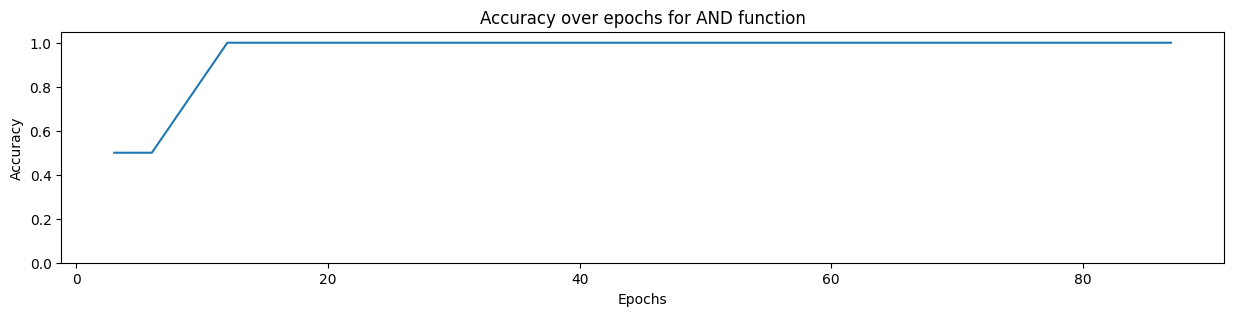

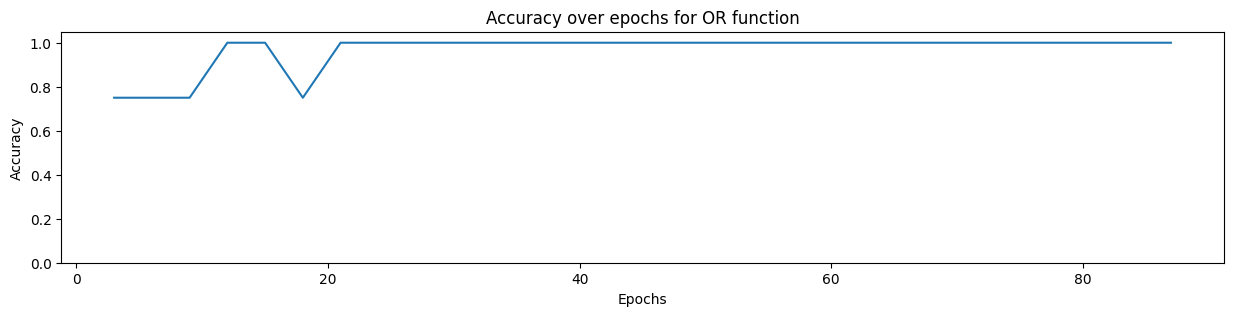

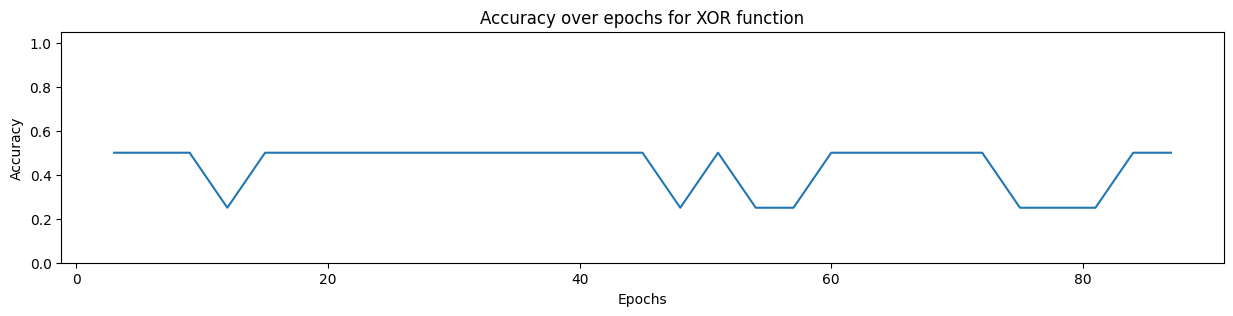

In [274]:
np.random.seed(1234)

q1_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
q1_and_labels = np.array([0, 0, 0, 1])
q1_or_labels = np.array([0, 1, 1, 1])
q1_xor_labels = np.array([0, 1, 1, 0])

# Make the figures for the AND, OR, and XOR functions
# next to each other

def plot_error_over_epochs(X, Y, title="Accuracy over epochs"):
    epoch_numbers = [3 * i for i in range(1, 30)]
    accuracies = []
    for epoch_number in epoch_numbers:
        p = Perceptron(2)
        p.train(X, Y, epochs=epoch_number)
        accuracies.append(accuracy(p.predict(X), Y))

    plt.figure(figsize=(15, 3))
    plt.plot(epoch_numbers, accuracies)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.show()

plot_error_over_epochs(q1_train, q1_and_labels, title="Accuracy over epochs for AND function")
plot_error_over_epochs(q1_train, q1_or_labels, title="Accuracy over epochs for OR function")
plot_error_over_epochs(q1_train, q1_xor_labels, title="Accuracy over epochs for XOR function")

#### Question 2

<div style="background-color:#f1be3e">

_Write your answer here._

</div>
We will need 10 input neurons. This is because the input neurons equals the features of the input. We are given that we want to transform a 10 feature input so we will need 10 neurons. Each specific feature is mapped to a neuron.


#### Question 3

<div style="background-color:#f1be3e">

_Write your answer here._

</div>
We will need 7 output neurons. This is because the number of output neurons is equal to the number of output classes to which we classify the input. In our case we want to classify the input into 1 out of 7 classes, so we need 7 output neurons.


#### Question 4

<div style="background-color:#f1be3e">

_Write your answer here._

</div>
By the Universal Approximation Theorem 1 layer is enough for any classification task. This is a solid starting point because a single hidden layer can handle most basic classification tasks without making the math too complicated. I chose 16 neurons - comparable to the number of input features, which gives the model enough neurons to find patterns without overcomplicating things.

#### Question 5

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

Based on the fact that we will have one single class label as an output per sample, we would use the softmax function as the activation function for the output layer. The reason for this is that it gives mutually exclusive labels where it outputs probability scores for each class, and we would select the class with the highest probability.

For the hidden layers, we would use a ReLU. The vanishing gradient problem occurs when gradients become exponentially small during backpropagation due to repeated multiplication of derivatives less than 1. This prevents early layers from learning effectively, making deep networks difficult to train. Activation functions like sigmoid and tanh cause this because their derivatives are bounded below 1. ReLU mitigates this problem since its derivative is 1 for positive inputs, preventing gradient shrinkage.

#### Question 6

<div style="background-color:#f1be3e">

_Write your answer here. You can include images using the syntax !.[title].(filepath), removing decimal points therein._

</div>

### 1.3 Neural network implementation

In [275]:
class Linear:
    def __init__(self, in_features, out_features, init_strategy="zeros"):

        if init_strategy == "normal":
            mu, sigma = 0, 1
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features)) # (d,k)
        elif init_strategy == "xavier":
            mu, sigma = 0, np.sqrt(1/in_features)
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features))
        elif init_strategy == "he":
            mu, sigma = 0, np.sqrt(2/in_features)
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features))
        elif init_strategy == "uniform":
            self.weight = np.random.uniform(-0.1, 0.1, size=(in_features, out_features))
        else:
            self.weight = np.zeros(shape=(in_features, out_features))

        self.bias = np.zeros(out_features) # (k,)

        self.cache = None
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        self.cache = x # (n,d)
        return x @ self.weight + self.bias # (n,d)(d,k) + (k,) = (n,k) + (n,k) broadcasted = (n,k)

    def backward(self, dupstream):
       # dupstream is (n,k)
        self.weight_grad = self.cache.T @ dupstream # (d,n)(n,k) = (d,k)
        self.bias_grad = np.sum(dupstream, axis=0) #(n,k) sum axis 0 = (k,)
        return dupstream @ self.weight.T # (n,k)(k,d) = (n,d)

In [276]:
class Sigmoid:

    def apply(self, x):
        return 1 / (1 + np.exp(-x))

    def apply_derivative(self, x):
        return self.apply(x) * (1 - self.apply(x))

In [277]:
class ReLU:

    def apply(self, x):
        return np.maximum(0, x)

    def apply_derivative(self, x):
        return np.where(x <= 0, 0, 1)

In [278]:
class Activation:
    def __init__(self, function):
        self.cache = None
        self.function = function

    def forward(self, x):
        self.cache = x #(n,k)
        return self.function.apply(x) #(n,k)

    def backward(self, dupstream):
        # dupstream is (n,k)
        return dupstream * self.function.apply_derivative(self.cache) #(n,k) * C

In [279]:
class BinaryCrossEntropy:
    def value(self, labels, logits):
        eps = 1e-9  # numerical stability
        y = labels.reshape(-1, 1) # (n,1)
        return -np.mean(y * np.log(logits + eps) + (1 - y) * np.log(1 - logits + eps))

    def grad(self, labels, logits):
        eps = 1e-9
        y = labels.reshape(-1, 1) # (n,1)
        return (-y / (logits + eps) + (1 - y) / (1 - logits + eps)) / y.shape[0]

In [280]:
class SoftmaxCrossEntropy:

    def softmax(self, logits):
        # Stable softmax taken from the web
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(shifted)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def value(self, labels, logits):
        n = logits.shape[0]
        probs = self.softmax(logits)
        return -np.mean(np.log(probs[np.arange(n), labels]))

    def grad(self, labels, logits):
        n = logits.shape[0]
        probs = self.softmax(logits)
        probs[np.arange(n), labels] -= 1
        return probs / n


In [281]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        logits = x
        for layer in self.layers:
            logits = layer.forward(logits)

        return logits

    def backward(self, dupstream):
        gradient = dupstream
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)
        return gradient

    def optimizer_step(self, lr):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad


In [282]:
def train(net,
          train_data, train_labels,
          val_data, val_labels,
          loss, mapToLabel, lr=0.1, epochs=1000,
          batch_size=None,
          early_stopping=False,
          patience=20,
          min_delta=0.001):

    losses = []
    accuracies = []
    n = train_data.shape[0]

    best_validation_loss = float('inf')
    epochs_without_improvement = 0
    stopping_epoch = epochs

    for epoch in range(epochs):

        indices = np.random.permutation(n)
        inputs_shuffled = train_data[indices]
        labels_shuffled = train_labels[indices]

        epoch_loss = 0

        # Normal case like before
        if batch_size is None:
            logits = net.forward(inputs_shuffled)
            loss_val = loss.value(labels_shuffled, logits)
            loss_grad = loss.grad(labels_shuffled, logits)

            net.backward(loss_grad)
            net.optimizer_step(lr)

            epoch_loss = loss_val

        else:
            for i in range(0, n, batch_size):
                X_batch = inputs_shuffled[i:i+batch_size]
                y_batch = labels_shuffled[i:i+batch_size]

                logits = net.forward(X_batch)
                loss_val = loss.value(y_batch, logits)
                loss_grad = loss.grad(y_batch, logits)

                net.backward(loss_grad)
                net.optimizer_step(lr)

                epoch_loss += loss_val * len(X_batch)

            epoch_loss /= n

        logits_full = net.forward(train_data)
        acc = accuracy(train_labels, mapToLabel(logits_full))

        losses.append(epoch_loss)
        accuracies.append(acc)

        if early_stopping:
            logits_val = net.forward(val_data)
            loss_val_validation = loss.value(val_labels, logits_val)

            if loss_val_validation < best_validation_loss - min_delta:
                best_validation_loss = loss_val_validation
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                stopping_epoch = epoch + 1
                break

    return losses, accuracies, stopping_epoch

### Data Preprocessing

We split our data into a training, validation and test set. We will use 70% of the data for training, 15% for validation and 15% for testing. We will use the training set to train our network, the validation set to tune our hyperparameters and the test set to evaluate our final model. The unknown set will be used to make predictions with our final model.

We will apply feature normalisation to the data. This is because it can help with the convergence of the network, and it can also help with the performance of the network. We will also transform the class labels to the range [0, 6] instead of [1, 7] because it is easier to work with zero indexed labels in the code.

In [283]:
np.random.seed(1234)

num_samples = features.shape[0]

labels = targets.astype(int) - 1

indices = np.arange(num_samples)
np.random.shuffle(indices)
# Apply shuffle to features and targets
features_shuffled = features[indices] # Transform labels to range [0, 6]
targets_shuffled = labels[indices]

train_end = int(0.7 * num_samples)
val_end = int(0.85 * num_samples)

X_train = features_shuffled[:train_end]
y_train = targets_shuffled[:train_end]

X_val = features_shuffled[train_end:val_end]
y_val = targets_shuffled[train_end:val_end]

X_test = features_shuffled[val_end:]
y_test = targets_shuffled[val_end:]

In [284]:
mean, std = np.mean(X_train, axis=0), np.std(X_train, axis=0)
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

### Implementation verification

In [285]:
def plot_accuracy_loss(losses, accuracies, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(20, 3))
    axes[0].plot(losses, color="red")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_ylim(0, max(losses) * 1.1)
    axes[0].set_title(title + "Loss over epochs")

    axes[1].plot(accuracies, color="green")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(title + "Accuracy over epochs")
    plt.show()

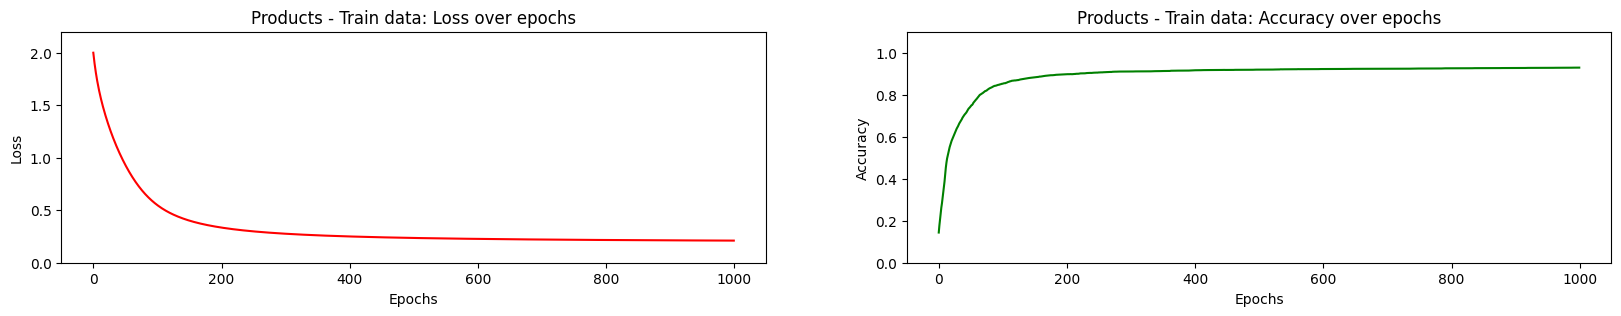

Final accuracy on train set: 0.9290522102965254
Accuracy on validation set: 0.9286926994906621
Accuracy on test set: 0.9304495335029687


In [286]:
np.random.seed(1234)

p = Network([Linear(10, 7, init_strategy="he"), Activation(ReLU()),
             Linear(7, 7, init_strategy="xavier")])

losses, accuracies, epochs = train(p,
                           X_train, y_train,
                           X_val, y_val,
                           SoftmaxCrossEntropy(),
                           lambda x: np.argmax(x, axis=1),
                           lr=0.1,
                           epochs=1000)

plot_accuracy_loss(losses, accuracies, title="Products - Train data: ")
print("Final accuracy on train set:", accuracies[-1])

predicted_labels = np.argmax(p.forward(X_val), axis=1)

validation_accuracy = accuracy(y_val, predicted_labels)
print("Accuracy on validation set:", validation_accuracy)

predicted_labels_test = np.argmax(p.forward(X_test), axis=1)
test_accuracy = accuracy(y_test, predicted_labels_test)
print("Accuracy on test set:", test_accuracy)

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
To obtain an unbiased estimate of the model's performance, we divide our dataset into three disjoint subsets - a training set(70%), a validation set (15%) and a test set(15%). The training set is used to train the network and learn the correct parameters, the validation set is used to tune hyperparameters such as the leearning rate and number of epochs, and the test set for evaluating the final model performance.

Before splitting, we randomly shuffle the dataset using a ranodmly permuted index array. This shuffled index array is applied to both feature smatrix and the target labels. Random shuffling ensures that samples are distributed randomly across the trainingmvalidation and test sets preventing any ordering bias that could affect model evaluation.

Since the original dataset is balanced, with each class containing approximately the same number of samples, random shuffling preserves similar class proportions across all subsets. This ensures that the model is trained and evaluated on representative data, preventing bias toward any specific class and enabling reliable performance estimation.

To ensure reproducibility, the random number generator can be initialized with a fixed seed before shuffling. This guarantees that the same data split is produced every time the experiment is run, allowing consistent and reproducible results. We use this technique many times.

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
We use accuracy on the validation set as the primary performence metric. This is beause of the nature of the task and it is easy to evaluate - if the predicted == real we have it correct. We chose multi class Cross-Entropy Loss for the optimization phase because it is mathematically coupled with the Softmax output layer. Unlike Mean Squared Error, Cross-Entropy heavily penalizes confident but wrong predictions, driving the network to learn faster and more robustly in multi-class classification tasks.

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
We have implemented early stopping in our train function which stops early when the loss does not decrease more than 20 times consecutively. By doing this we ensure that we stop training the model after we stop progressing. By actively monitoring a validation set, early stopping halts the training at the exact point where the model's ability to generalize stops improving, preventing overfitting and saving computational time.

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

In [287]:
np.random.seed(1234)

# Fix a network with 1 layer
# Each layer will have a number of neurons in the range [7, 30]
neurons = [7, 13, 19, 25, 30]
neurons_to_average_acc = []
num_iter = 10

for neuron_count in neurons:

    accuracies_for_setup = []
    for _ in range(num_iter):

        p = Network([Linear(10, neuron_count, init_strategy="he"), Activation(ReLU()),
                     Linear(neuron_count, 7, init_strategy="xavier")])

        train(p,
                X_train, y_train,
                X_val, y_val,
                SoftmaxCrossEntropy(),
                lambda x: np.argmax(x, axis=1),
                lr=0.1,
                epochs=500)

        predicted_labels = np.argmax( p.forward(X_val), axis=1)
        accuracies_for_setup.append(accuracy(y_val, predicted_labels))

    neurons_to_average_acc.append(np.mean(accuracies_for_setup))

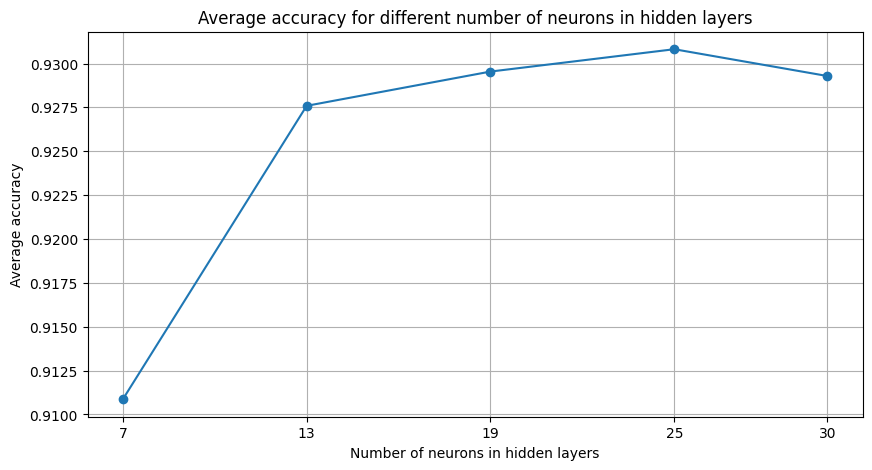

In [289]:
plt.figure(figsize=(10, 5))
plt.plot(neurons, neurons_to_average_acc, marker="o")
plt.title("Average accuracy for different number of neurons in hidden layers")
plt.xlabel("Number of neurons in hidden layers")
plt.ylabel("Average accuracy")
plt.xticks(neurons)
plt.grid()
plt.show()

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>